# Pulsed Laser Beam Waist Analysis
Knife-edge measurements to determine beam waist profile along the propagation axis.

In [1]:
%matplotlib inline
import importlib
import pulsed_laser_waist
importlib.reload(pulsed_laser_waist)
from pulsed_laser_waist import read_pulsed_csv, erf_model, erf_model_flipped, fit_erf_anchored
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt


## Parameters â€” edit these before running

In [6]:
# Path to folder containing the diodexx_knife_in_yy_zz.csv files
folder = r"F:\Lab data\20260311\vertical knive edge"

# Minimum number of samples between detected peaks
min_peak_distance = 50

# Minimum peak prominence (None = auto: 5% of each file's signal range)
min_peak_prominence = None

# Set True to plot raw data + detected peaks for every file
plot_peaks = False

# RÂ² threshold below which the flipped ERF is tried
r2_threshold = 0.95

# Physical distance per knife-edge step (Âµm)
dist = 200  # Âµm per yy increment

# Initial guess for ERF fit [x0, p_max, w] â€” None for auto-estimate
erf_p0 = None

## Step 1 â€” Read CSV files and compute average power per knife position

In [7]:
yy_positions, avg_power, per_file_avgs = read_pulsed_csv(
    folder,
    min_peak_distance=min_peak_distance,
    min_peak_prominence=min_peak_prominence,
    plot=plot_peaks
)

diode80_knife_in_00_0.csv  ->  20 peaks,  mean peak power = 1.5839
diode80_knife_in_00_1.csv  ->  20 peaks,  mean peak power = 1.5840
diode80_knife_in_00_2.csv  ->  20 peaks,  mean peak power = 1.5841
diode80_knife_in_00_3.csv  ->  20 peaks,  mean peak power = 1.5842
diode80_knife_in_00_4.csv  ->  20 peaks,  mean peak power = 1.5842
diode80_knife_in_00_5.csv  ->  20 peaks,  mean peak power = 1.5841
diode80_knife_in_00_6.csv  ->  20 peaks,  mean peak power = 1.5844
diode80_knife_in_00_7.csv  ->  20 peaks,  mean peak power = 1.5844
diode80_knife_in_00_8.csv  ->  20 peaks,  mean peak power = 1.5845
diode80_knife_in_00_9.csv  ->  20 peaks,  mean peak power = 1.5846
diode80_knife_in_01_0.csv  ->  20 peaks,  mean peak power = 1.5822
diode80_knife_in_01_1.csv  ->  20 peaks,  mean peak power = 1.5824
diode80_knife_in_01_2.csv  ->  20 peaks,  mean peak power = 1.5826
diode80_knife_in_01_3.csv  ->  20 peaks,  mean peak power = 1.5827
diode80_knife_in_01_4.csv  ->  20 peaks,  mean peak power = 1.

## Step 2 â€” Plot average power vs knife position

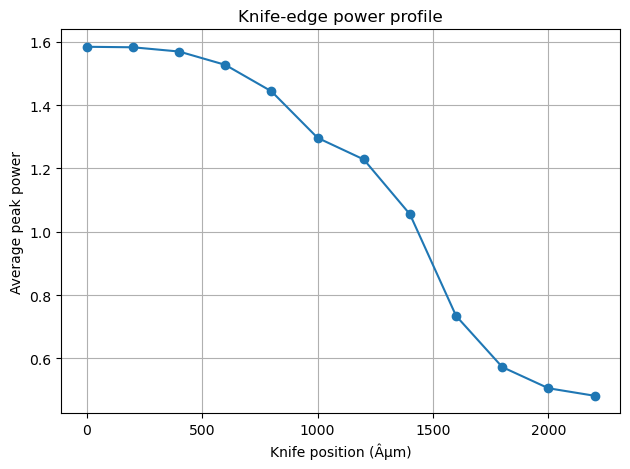

In [8]:
x_pos = np.array(yy_positions) * dist

fig, ax = plt.subplots()
ax.plot(x_pos, avg_power, 'o-')
ax.set_xlabel('Knife position (Âµm)')
ax.set_ylabel('Average peak power')
ax.set_title('Knife-edge power profile')
ax.grid(True)
plt.tight_layout()
plt.show()

## Step 3 â€” Fit knife-edge data to error function

y_top (anchored)    = 1.5787  (mean of first 3 points)
y_bottom (anchored) = 0.5203  (mean of last  3 points)
x0                  = 1321.15 µm
w (beam waist)      = 760.27 µm
R²                  = 0.98718


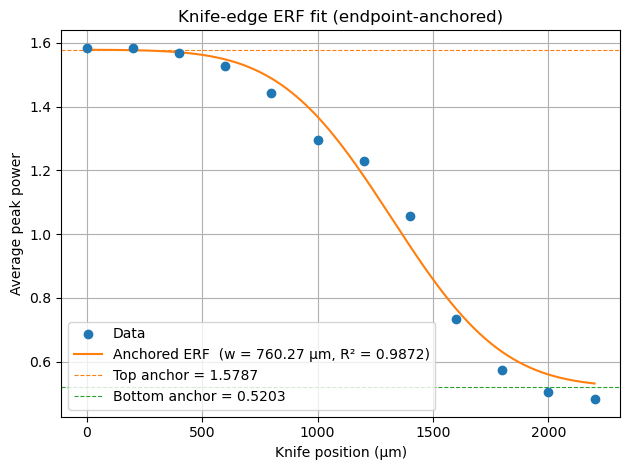

In [9]:
x = np.array(yy_positions, dtype=float) * dist
y = np.array(avg_power,    dtype=float)

# Number of endpoint points to average for asymptote anchoring.
# Increase if the flat regions at either end span more positions.
n_flat = 3

x0_fit, w_fit, y_top, y_bottom, r2, model_fn = fit_erf_anchored(x, y, n_flat=n_flat)

print(f"y_top (anchored)    = {y_top:.4f}  (mean of first {n_flat} points)")
print(f"y_bottom (anchored) = {y_bottom:.4f}  (mean of last  {n_flat} points)")
print(f"x0                  = {x0_fit:.2f} µm")
print(f"w (beam waist)      = {w_fit:.2f} µm")
print(f"R²                  = {r2:.5f}")

x_fine = np.linspace(x.min(), x.max(), 500)
y_fit  = model_fn(x_fine)

fig, ax = plt.subplots()
ax.plot(x, y, 'o', label='Data', zorder=5)
ax.plot(x_fine, y_fit, label=f'Anchored ERF  (w = {w_fit:.2f} µm, R² = {r2:.4f})')
ax.axhline(y_top,    color='C1', linestyle='--', linewidth=0.8, label=f'Top anchor = {y_top:.4f}')
ax.axhline(y_bottom, color='C2', linestyle='--', linewidth=0.8, label=f'Bottom anchor = {y_bottom:.4f}')
ax.set_xlabel('Knife position (µm)')
ax.set_ylabel('Average peak power')
ax.set_title('Knife-edge ERF fit (endpoint-anchored)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
